In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import random

# Load the dataset
file_path = r"D:\NITJ\AI\project\heart diseases\heart.csv"
data = pd.read_csv(file_path)

# Encode categorical variables
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# Separate features and target
X = data.drop('HeartDisease', axis=1).values
y = data['HeartDisease'].values

# Standardize numerical features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Apply SMOTE for handling class imbalance
smote = SMOTE(sampling_strategy='auto', random_state=42)
X, y = smote.fit_resample(X, y)

# Genetic Algorithm for Feature Selection
class GeneticAlgorithmFeatureSelector:
    def __init__(self, X, y, population_size=20, generations=50, mutation_rate=0.1):
        self.X = X
        self.y = y
        self.population_size = population_size
        self.generations = generations
        self.mutation_rate = mutation_rate
        self.num_features = X.shape[1]

    def initialize_population(self):
        # Random binary strings representing feature subsets
        return [np.random.randint(2, size=self.num_features) for _ in range(self.population_size)]

    def fitness(self, individual):
        # Evaluate Random Forest accuracy using selected features
        selected_features = [i for i in range(self.num_features) if individual[i] == 1]
        if len(selected_features) == 0:  # Avoid empty feature subset
            return 0
        X_selected = self.X[:, selected_features]
        X_train, X_test, y_train, y_test = train_test_split(X_selected, self.y, test_size=0.2, random_state=42)
        
        model = RandomForestClassifier(random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        return accuracy_score(y_test, y_pred)

    def selection(self, population, fitness_scores):
        # Select top individuals based on fitness scores
        sorted_indices = np.argsort(fitness_scores)[::-1]
        return [population[i] for i in sorted_indices[:len(population) // 2]]

    def crossover(self, parent1, parent2):
        # Single-point crossover
        point = random.randint(1, self.num_features - 1)
        child1 = np.concatenate([parent1[:point], parent2[point:]])
        child2 = np.concatenate([parent2[:point], parent1[point:]])
        return child1, child2

    def mutate(self, individual):
        # Randomly flip a bit
        for i in range(self.num_features):
            if random.random() < self.mutation_rate:
                individual[i] = 1 - individual[i]  # Flip 0 to 1 or 1 to 0
        return individual

    def evolve(self):
        # Initialize population
        population = self.initialize_population()

        for generation in range(self.generations):
            fitness_scores = [self.fitness(individual) for individual in population]
            print(f"Generation {generation + 1}: Best Fitness = {max(fitness_scores):.4f}")

            # Selection
            selected = self.selection(population, fitness_scores)

            # Crossover and Mutation
            next_generation = []
            while len(next_generation) < self.population_size:
                parent1, parent2 = random.sample(selected, 2)
                child1, child2 = self.crossover(parent1, parent2)
                next_generation.append(self.mutate(child1))
                next_generation.append(self.mutate(child2))

            population = next_generation

        # Final population fitness evaluation
        final_fitness = [self.fitness(ind) for ind in population]
        best_individual = population[np.argmax(final_fitness)]
        return best_individual, max(final_fitness)

# Run Genetic Algorithm for Feature Selection
ga_selector = GeneticAlgorithmFeatureSelector(X, y, population_size=20, generations=30, mutation_rate=0.1)
best_features, best_fitness = ga_selector.evolve()

# Evaluate model with selected features
selected_indices = [i for i in range(X.shape[1]) if best_features[i] == 1]
X_selected = X[:, selected_indices]
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

final_model = RandomForestClassifier(random_state=42)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

# Results
print("Selected Features:", selected_indices)
print(f"Final Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")


Generation 1: Best Fitness = 0.8578
Generation 2: Best Fitness = 0.8627
Generation 3: Best Fitness = 0.8676
Generation 4: Best Fitness = 0.8775
Generation 5: Best Fitness = 0.8775
Generation 6: Best Fitness = 0.9020
Generation 7: Best Fitness = 0.8775
Generation 8: Best Fitness = 0.9020
Generation 9: Best Fitness = 0.8775
Generation 10: Best Fitness = 0.8775
Generation 11: Best Fitness = 0.8922
Generation 12: Best Fitness = 0.9020
Generation 13: Best Fitness = 0.9020
Generation 14: Best Fitness = 0.9020
Generation 15: Best Fitness = 0.9020
Generation 16: Best Fitness = 0.9020
Generation 17: Best Fitness = 0.9020
Generation 18: Best Fitness = 0.9020
Generation 19: Best Fitness = 0.9020
Generation 20: Best Fitness = 0.8873
Generation 21: Best Fitness = 0.8873
Generation 22: Best Fitness = 0.9020
Generation 23: Best Fitness = 0.9020
Generation 24: Best Fitness = 0.8922
Generation 25: Best Fitness = 0.9020
Generation 26: Best Fitness = 0.9020
Generation 27: Best Fitness = 0.9020
Generation

Confusion Matrix:
[[ 74  14]
 [  8 108]]


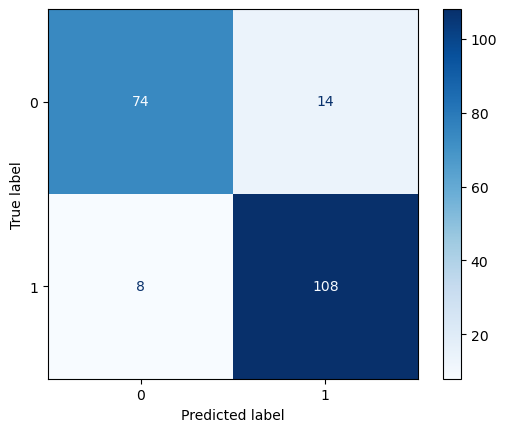

In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_model.classes_)
disp.plot(cmap="Blues")